In [1]:


# Execute this first 
#
#  * trigger notebook styling
#  * check if notebook had been modified since its distribution
# 
# Note: executing any cells before this modifies the notebook.
# 

import os

# Add Homebrew's bin folder to the system path used by Jupyter
os.environ['PATH'] += ":/opt/homebrew/bin"

# Test if it works now
!gmx -version

#check_notebook()

                     :-) GROMACS - gmx, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx -version

GROMACS version:     2025.4-Homebrew
Precision:           mixed
Memory model:        64 bit
MPI library:         thread_mpi
OpenMP support:      enabled (GMX_OPENMP_MAX_THREADS = 128)
GPU support:         disabled
SIMD instructions:   ARM_NEON_ASIMD
CPU FFT library:     fftw-3.3.10
GPU FFT library:     none
Multi-GPU FFT:       none
TNG support:         enabled
Hwloc support:       disabled
Tracing support:     disabled
C compiler:          /opt/homebrew/opt/gcc/bin/gcc-15
C compiler flags:    -fexcess-precision=fast -funroll-all-loops -Wno-missing-field-initializers -O3 -DNDEBUG
C++ compiler:        /opt/homebrew/opt/gcc/bin/g++-15
C++ compiler flags:  -fexcess-precision=fast -funroll-all-loops -Wno-missing-field-initi

In [2]:
%pip install nglview pandas mdtraj numpy matplotlib
import nglview as ng
import pandas as pd
import mdtraj as md
import numpy as np
import matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
%cd ~/cp2k/D2O_ice/GroMACK
!ls

/Users/mackenziehenley/cp2k/D2O_ice/GroMACK
#d2o_solvated.gro.1#        gromacs_lattice.gro
#d2o_solvated.gro.2#        gromacs_lattice.pdb
#density1.xvg.1#            gromacs_lattice.xyz.xtc
#density1.xvg.2#            md_dos_fixed.cpt
#density2.xvg.1#            md_dos_fixed.edr
#gromacs_lattice.pdb.1#     md_dos_fixed.gro
#gromacs_lattice.xyz.xtc.1# md_dos_fixed.log
#gromacs_lattice.xyz.xtc.2# md_dos_fixed.tpr
#npt1.edr.1#                md_dos_fixed.trr
#npt1.edr.2#                mdout.mdp
#npt1.gro.1#                mvacf.xvg
#npt1.gro.2#                npt1_prev.cpt
#npt1.gro.3#                npt1.cpt
#npt1.log.1#                npt1.edr
#npt1.log.2#                npt1.gro
#npt1.tpr.1#                npt1.log
#npt1.tpr.2#                npt1.mdp
#npt1.trr.1#                npt1.tpr
#npt1.trr.2#                npt1.trr
#npt1.xtc.1#                npt1.xtc
#npt1.xtc.2#                npt2.cpt
#pressure.xvg.1#            npt2.edr
#pressure.xvg.2#            npt2.gro
#pressure2.xv

In [4]:
# Load and view the .pdb or .gro file with the following lines
view = ng.show_structure_file("d2o_ice.gro")
view

NGLWidget()

In [5]:
# Create a single D2O molecule file for GROMACS to copy
with open("single_d2o.gro", "w") as f:
    f.write("Single D2O Molecule Template\n")  # Title
    f.write("4\n")                             # Number of atoms (OW, DW1, DW2, MW)
    f.write("    1ICE     OW    1   1.694   0.176   2.149\n")
    f.write("    1ICE    DW1    2   1.697   0.271   2.145\n")
    f.write("    1ICE    DW2    3   1.740   0.147   2.070\n")
    f.write("    1ICE     MW    4   1.700   0.184   2.138\n")
    # The box size (placeholder)
    f.write("   2.80000   2.80000   2.80000\n")

print("Created 'single_d2o.gro'.")

Created 'single_d2o.gro'.


In [6]:
# Add the Deuterium Ice Molecules to the larger box
!gmx insert-molecules -box 1.4 1.4 1.4 -ci single_d2o.gro -nmol 32 -o d2o_solvated.gro -seed 12345 -try 10000

            :-) GROMACS - gmx insert-molecules, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx insert-molecules -box 1.4 1.4 1.4 -ci single_d2o.gro -nmol 32 -o d2o_solvated.gro -seed 12345 -try 10000

Initialising inter-atomic distances...

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx insert-molecules uses the Van der Waals radii
from the source below. This means the results may be different
compared

In [7]:
# View the system
view = ng.show_structure_file("d2o_solvated.gro")
view.add_representation(repr_type='ball+stick', selection='ICE')
view.camera='orthographic'
view

NGLWidget()

In [9]:
filename = "topol.top"
molecule_name = "D2O_flex" 
# Changed to 32 to match CP2K exactly (32 molecules * 3 atoms = 96 atoms)
correct_count = 32          

with open(filename, 'r') as f:
    lines = f.readlines()

new_lines = []
found_molecules_section = False

for line in lines:
    # Adding spaces inside the brackets makes it robust against GROMACS formatting
    if "[ molecules ]" in line or "[molecules]" in line:
        found_molecules_section = True
        new_lines.append(line)
        new_lines.append("; Compound        #mols\n")
        break # Stop reading the old file here
    new_lines.append(line)

# Append the correct count if we found the section
if found_molecules_section:
    new_lines.append(f"{molecule_name:<15} {correct_count}\n")
    
    with open(filename, 'w') as f:
        f.writelines(new_lines)
    print(f"FIXED: topol.top now correctly lists {correct_count} molecules of {molecule_name} for the M3 chip!")
else:
    print(" ERROR: Could not find the '[ molecules ]' section in topol.top")

FIXED: topol.top now correctly lists 32 molecules of D2O_flex for the M3 chip!


In [10]:
import os

input_gro = "d2o_solvated.gro"
output_gro = "d2o_clean.gro"
topology_file = "topol.top"
molecule_name = "D2O_flex"

# 1. (Remove MW atoms)
print(f"[STATUS] Cleaning {input_gro} to match 3-site flexible topology...")
with open(input_gro, 'r') as f:
    lines = f.readlines()

header = lines[0]
box_line = lines[-1]
atom_lines = lines[2:-1] 

new_atom_lines = []
for line in atom_lines:
    if "MW" not in line:
        new_atom_lines.append(line)

# Calculate new counts
total_atoms = len(new_atom_lines)
num_molecules = total_atoms // 3 

with open(output_gro, 'w') as f:
    f.write(header)
    f.write(f"{total_atoms:>5}\n") # Update the count header (formatted)
    f.writelines(new_atom_lines)
    f.write(box_line)

print(f"'{output_gro}' with {total_atoms} atoms (removed MWs).")
print(f" Calculated Molecule Count: {num_molecules}")


print(f"Updating {topology_file}...")

with open(topology_file, 'r') as f:
    top_lines = f.readlines()

new_top_lines = []
found_molecules = False

for line in top_lines:
    if "[molecules]" in line:
        found_molecules = True
        new_top_lines.append(line)
        new_top_lines.append("; Compound        #mols\n")
        # We stop adding old lines here to avoid duplicates
        break 
    new_top_lines.append(line)

if found_molecules:
    new_top_lines.append(f"{molecule_name:<15} {num_molecules}\n")
    
    with open(topology_file, 'w') as f:
        f.writelines(new_top_lines)
    print(f"Topology updated: {molecule_name} = {num_molecules}")
else:
    print("Could not find [ molecules ] section in topology.")

[STATUS] Cleaning d2o_solvated.gro to match 3-site flexible topology...
'd2o_clean.gro' with 96 atoms (removed MWs).
 Calculated Molecule Count: 32
Updating topol.top...
Topology updated: D2O_flex = 32


In [13]:
#Energy Minimization
!gmx grompp -f em.mdp -c d2o_clean.gro -p topol.top -o em.tpr
!gmx mdrun -deffnm em -ntmpi 1 -ntomp 1

                 :-) GROMACS - gmx grompp, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx grompp -f em.mdp -c d2o_clean.gro -p topol.top -o em.tpr

Ignoring obsolete mdp entry 'ns_type'

NOTE 1 [file em.mdp]:
  With Verlet lists the optimal nstlist is >= 10, with GPUs >= 20. Note
  that with the Verlet scheme, nstlist has no effect on the accuracy of
  your simulation.

Setting the LD random seed to -318811721

Generated 3 of the 3 non-bonded parameter combinations

Excluding 2 bonded neighbours molecule type 'D2O_flex'
Analysing residue names:
There are:    32      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coupling group rest is 285.00
The integrator does not provide a ensemble temperature, there is no system ensemble te

In [14]:
#Analyze results of EM
!printf "Potential\n0\n" | gmx energy -f em.edr -o potential.xvg -xvg none

                 :-) GROMACS - gmx energy, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx energy -f em.edr -o potential.xvg -xvg none

Opened em.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  LJ-(SR)          4  Disper.-corr. 
  5  Coulomb-(SR)     6  Coul.-recip.     7  Potential        8  Pres.-DC      
  9  Pressure        10  Vir-XX          11  Vir-XY          12  Vir-XZ        
 13  Vir-YX          14  Vir-YY          15  Vir-YZ          16  Vir-ZX        
 17  Vir-ZY          18  Vir-ZZ          19  Pres-XX         20  Pres-XY       
 21  P

<Axes: xlabel='step'>

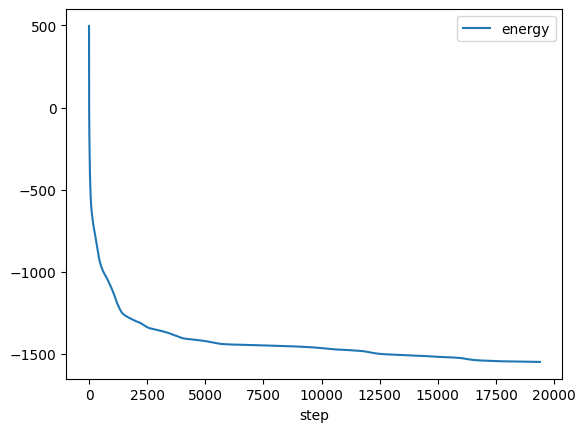

In [15]:
# Print graph
df = pd.read_csv('potential.xvg', sep='\\s+', header=None, names=['step','energy'])
df.plot('step')

In [17]:
# Temperature EQ T=94K
!gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr 
!gmx mdrun -ntmpi 1 -ntomp 6 -v -deffnm nvt

                 :-) GROMACS - gmx grompp, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -1080181249

Generated 3 of the 3 non-bonded parameter combinations

Excluding 2 bonded neighbours molecule type 'D2O_flex'

Setting gen_seed to -759169737

Velocities were taken from a Maxwell distribution at 94 K
Analysing residue names:
There are:    32      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coupling group System is 285.00

The largest distance between excluded atoms is 0.165 nm between atom 5 and 6

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 94 K

Calculated rlist for 1x1 

In [18]:
# Analyze Temp run
!echo "Temperature" | gmx energy -f nvt.edr -o temperature.xvg -xvg none -b 20

                 :-) GROMACS - gmx energy, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx energy -f nvt.edr -o temperature.xvg -xvg none -b 20

Opened nvt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  LJ-(SR)          4  Disper.-corr. 
  5  Coulomb-(SR)     6  Coul.-recip.     7  Potential        8  Kinetic-En.   
  9  Total-Energy    10  Conserved-En.   11  Temperature     12  Pres.-DC      
 13  Pressure        14  Vir-XX          15  Vir-XY          16  Vir-XZ        
 17  Vir-YX          18  Vir-YY          19  Vir-YZ          20  Vir-ZX     

<Axes: xlabel='time'>

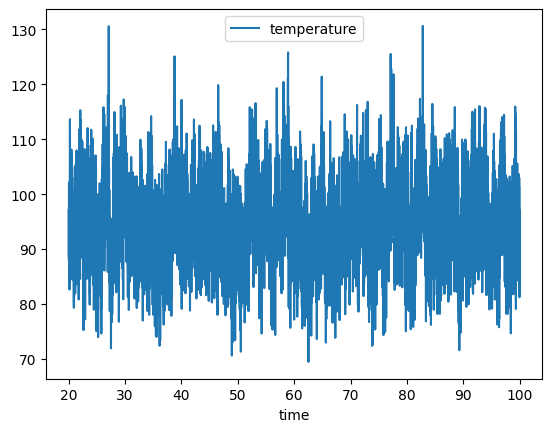

In [19]:
# Plot Temp data
df = pd.read_csv('temperature.xvg', sep='\\s+', header=None, names=['time','temperature'])
df.plot('time')
#!echo "Temperature" | gmx energy -f nvt.edr -o temperature.xvg -b 20
#!xmgrace temperature.xvg

In [25]:
# Pressure EQ P = 1.5 bars
!gmx grompp -f npt1.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt1.tpr -maxwarn 1
!gmx mdrun -ntmpi 1 -ntomp 8 -v -deffnm npt1

                 :-) GROMACS - gmx grompp, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx grompp -f npt1.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt1.tpr -maxwarn 1

Ignoring obsolete mdp entry 'ns_type'

WARNING 1 [file npt1.mdp]:
  The Berendsen barostat does not generate any strictly correct ensemble,
  and should not be used for new production simulations (in our opinion).
  We recommend using the C-rescale barostat instead.

Setting the LD random seed to -822370305

Generated 3 of the 3 non-bonded parameter combinations

Excluding 2 bonded neighbours molecule type 'D2O_flex'

Taking velocities from 'nvt.gro'
Analysing residue names:
There are:    32      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coupling

In [26]:
# Analyze Pressure Data
!echo "Pressure" | gmx energy -f npt1.edr -o pressure.xvg -xvg none

                 :-) GROMACS - gmx energy, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx energy -f npt1.edr -o pressure.xvg -xvg none

Opened npt1.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  LJ-(SR)          4  Disper.-corr. 
  5  Coulomb-(SR)     6  Coul.-recip.     7  Potential        8  Kinetic-En.   
  9  Total-Energy    10  Conserved-En.   11  Temperature     12  Pres.-DC      
 13  Pressure        14  Box-X           15  Box-Y           16  Box-Z         
 17  Volume          18  Density         19  pV              20  Enthalpy      
 21

<Axes: xlabel='time'>

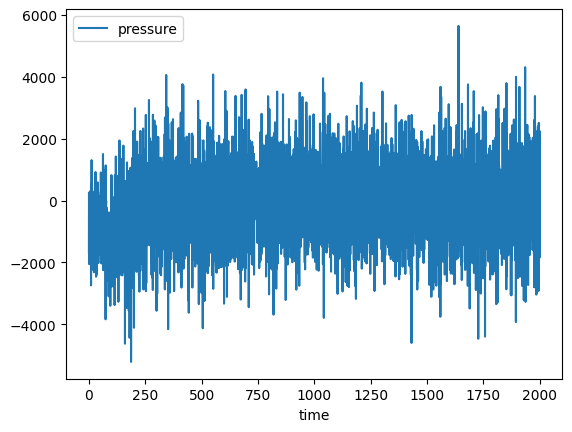

In [27]:
df = pd.read_csv('pressure.xvg', sep='\\s+', header=None, names=['time','pressure'])
df.plot('time')

In [35]:
#!echo "Pressure" | gmx energy -f npt.edr -o pressure.xvg
#!xmgrace pressure.xvg

                 :-) GROMACS - gmx energy, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx energy -f npt.edr -o pressure.xvg


-------------------------------------------------------
Program:     gmx energy, version 2025.4-Homebrew
Source file: src/gromacs/commandline/cmdlineparser.cpp (line 271)
Function:    void gmx::CommandLineParser::parse(int*, char**)

Error in user input:
Invalid command-line options
  In command-line option -f
    File 'npt.edr' does not exist or is not accessible.
    The file could not be opened.
      Reason: No such file or directory
      (call to fopen() returned error code 2)

For more information and tips for troubleshooting, please check the GROMACS
website at https://manual.gromacs.org/current/user-guide/run-time-errors.html
-------------------------------------------------------
z

In [28]:
# Look at density of system
!echo "Density" | gmx energy -f npt1.edr -o density1.xvg -xvg none

                 :-) GROMACS - gmx energy, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx energy -f npt1.edr -o density1.xvg -xvg none

Opened npt1.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  LJ-(SR)          4  Disper.-corr. 
  5  Coulomb-(SR)     6  Coul.-recip.     7  Potential        8  Kinetic-En.   
  9  Total-Energy    10  Conserved-En.   11  Temperature     12  Pres.-DC      
 13  Pressure        14  Box-X           15  Box-Y           16  Box-Z         
 17  Volume          18  Density         19  pV              20  Enthalpy      
 21

<Axes: xlabel='time'>

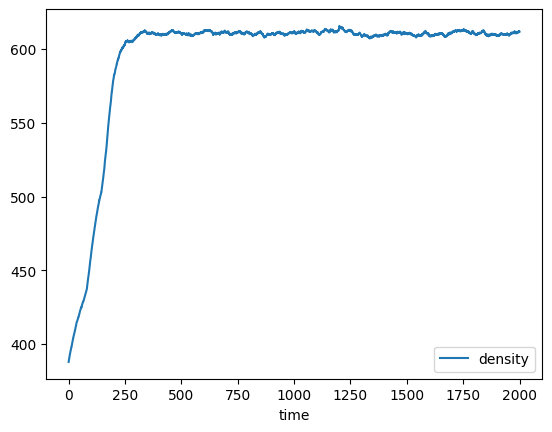

In [29]:
#Plot density
df = pd.read_csv('density1.xvg', sep='\\s+', header=None, names=['time','density'])
df.plot('time')

In [30]:
!tail -1 npt1.gro

   1.20264   1.20264   1.20264


In [39]:
#!gmx editconf -f npt1.gro -o npt1_expanded.gro -box 2.2 2.2 2.2 -c

In [32]:
# Pressure EQ Stage 2
!gmx grompp -f npt1.mdp -c npt1.gro -p topol.top -o npt2.tpr -maxwarn 1
!gmx mdrun -ntmpi 1 -ntomp 8 -v -deffnm npt2

                 :-) GROMACS - gmx grompp, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx grompp -f npt1.mdp -c npt1.gro -p topol.top -o npt2.tpr -maxwarn 1

Ignoring obsolete mdp entry 'ns_type'

WARNING 1 [file npt1.mdp]:
  The Berendsen barostat does not generate any strictly correct ensemble,
  and should not be used for new production simulations (in our opinion).
  We recommend using the C-rescale barostat instead.

Setting the LD random seed to -379595265

Generated 3 of the 3 non-bonded parameter combinations

Excluding 2 bonded neighbours molecule type 'D2O_flex'

Taking velocities from 'npt1.gro'
Analysing residue names:
There are:    32      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coupling group System is 285

                 :-) GROMACS - gmx energy, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx energy -f npt2.edr -o pressure2.xvg -xvg none

Opened npt2.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  LJ-(SR)          4  Disper.-corr. 
  5  Coulomb-(SR)     6  Coul.-recip.     7  Potential        8  Kinetic-En.   
  9  Total-Energy    10  Conserved-En.   11  Temperature     12  Pres.-DC      
 13  Pressure        14  Box-X           15  Box-Y           16  Box-Z         
 17  Volume          18  Density         19  pV              20  Enthalpy      
 2

<Axes: xlabel='time'>

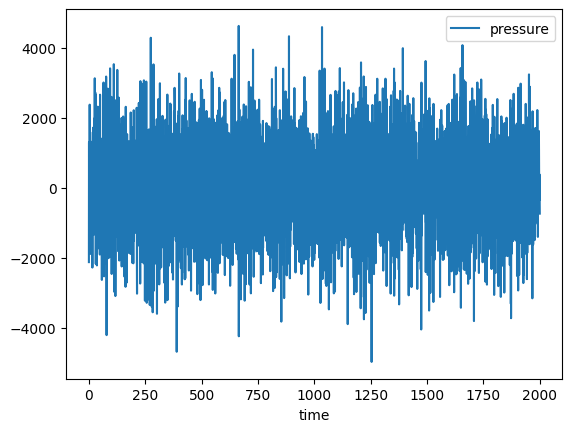

In [34]:
# Analyze Pressure Data
!echo "Pressure" | gmx energy -f npt2.edr -o pressure2.xvg -xvg none

df = pd.read_csv('pressure2.xvg', sep='\\s+', header=None, names=['time','pressure'])
df.plot('time')

                 :-) GROMACS - gmx energy, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx energy -f npt2.edr -o density2.xvg -xvg none

Opened npt2.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  LJ-(SR)          4  Disper.-corr. 
  5  Coulomb-(SR)     6  Coul.-recip.     7  Potential        8  Kinetic-En.   
  9  Total-Energy    10  Conserved-En.   11  Temperature     12  Pres.-DC      
 13  Pressure        14  Box-X           15  Box-Y           16  Box-Z         
 17  Volume          18  Density         19  pV              20  Enthalpy      
 21

<Axes: xlabel='time'>

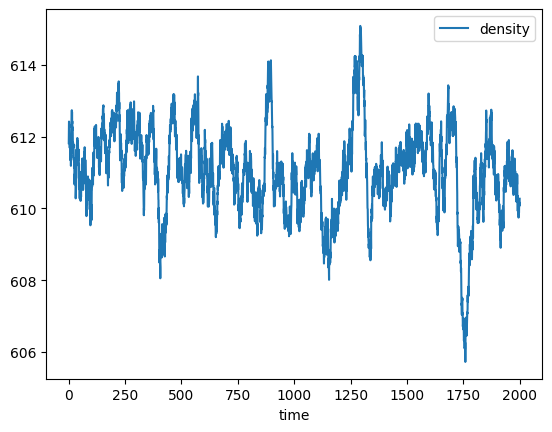

In [35]:
# Look at density of system
!echo "Density" | gmx energy -f npt2.edr -o density2.xvg -xvg none

#Plot density
df = pd.read_csv('density2.xvg', sep='\\s+', header=None, names=['time','density'])
df.plot('time')

In [37]:
# A. Generate the new run file
!gmx grompp -f d2o_production.mdp -c npt2.gro -p topol.top -o md_dos_fixed.tpr

# B. Run the short 20ps simulation (should take ~1 min)
!gmx mdrun -deffnm md_dos_fixed -v

# C. Calculate the VDOS
!echo "System" | gmx dos -f md_dos_fixed.trr -s md_dos_fixed.tpr -dos dos_fixed.xvg

                 :-) GROMACS - gmx grompp, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx grompp -f d2o_production.mdp -c npt2.gro -p topol.top -o md_dos_fixed.tpr

Setting the LD random seed to 1148678059

Generated 3 of the 3 non-bonded parameter combinations

Excluding 2 bonded neighbours molecule type 'D2O_flex'

Taking velocities from 'npt2.gro'
Analysing residue names:
There are:    32      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coupling group System is 285.00

The largest distance between excluded atoms is 0.169 nm between atom 8 and 9

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 94 K

Calculated rlist for 1x1 atom pair-list as 0.603 nm, buffer size 0.003 nm

Set rlist, assuming 4x4 atom pair

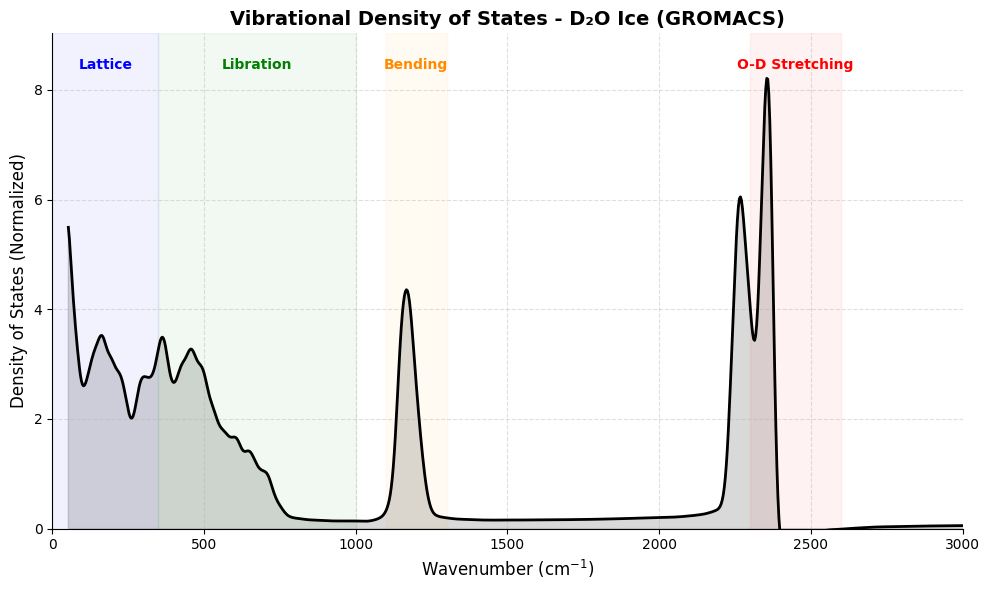

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d 

# 1. Load the data 
df_dos = pd.read_csv(
    'dos_fixed.xvg', 
    sep=r'\s+', 
    comment='@', 
    header=None,
    on_bad_lines='skip',
    engine='python'
)

# 2. Convert everything to numeric (turning stray text into NaN)
df_dos = df_dos.apply(pd.to_numeric, errors='coerce')

# 3. Drop rows that are completely NaN
df_dos = df_dos.dropna(how='all')

df_dos = df_dos.iloc[:, :2] 
df_dos.columns = ['freq', 'dos']

# 5. Convert Frequency (ps^-1) to Wavenumber (cm^-1)
df_dos['freq_cm'] = df_dos['freq'] * 33.35641

# --- APPLY SMOOTHING ---
df_dos['dos_smoothed'] = gaussian_filter1d(df_dos['dos'], sigma=4)

# 6. Create the plot
plt.figure(figsize=(10, 6)) # Matched size

if not df_dos.empty:
    # Plot smoothed line and fill (Black theme, no legend)
    plt.plot(df_dos['freq_cm'], df_dos['dos_smoothed'], color='black', linewidth=2)
    plt.fill_between(df_dos['freq_cm'], df_dos['dos_smoothed'], color='black', alpha=0.15)
    
    # --- Highlight Physics Regions for D2O ---
    max_y = df_dos['dos_smoothed'].max()
    label_height = max_y * 1.02 # Pushed high to the top
    
    # Lattice / Translation (< 350)
    plt.axvspan(0, 350, color='blue', alpha=0.05)
    plt.text(175, label_height, "Lattice", color='blue', ha='center', fontweight='bold')

    # Libration (350 - 1000)
    plt.axvspan(350, 1000, color='green', alpha=0.05)
    plt.text(675, label_height, "Libration", color='green', ha='center', fontweight='bold')

    # Bending (~1200)
    plt.axvspan(1100, 1300, color='orange', alpha=0.05)
    plt.text(1200, label_height, "Bending", color='darkorange', ha='center', fontweight='bold')

    # Stretching (~2300-2600)
    plt.axvspan(2300, 2600, color='red', alpha=0.05)
    plt.text(2450, label_height, "O-D Stretching", color='red', ha='center', fontweight='bold')

    # Styling
    plt.title('Vibrational Density of States - D₂O Ice (GROMACS)', fontsize=14, fontweight='bold')
    plt.xlabel('Wavenumber (cm$^{-1}$)', fontsize=12)
    plt.ylabel('Density of States (Normalized)', fontsize=12)
    
    # Optional: Turn off the top and right borders for a cleaner, modern look
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # Set limits
    plt.xlim(0, 3000) 
    plt.ylim(0, max_y * 1.1)
    
    # Formatting and saving
    plt.tight_layout()
    plt.savefig("gromack_3_25_d2o.jpg", dpi=300) 
    plt.show()
else:
    print("The dataframe is empty.")

In [7]:
!echo "0" | gmx trjconv -f em.trr -s em.tpr -o gromacs_lattice.xyz -pbc mol

                 :-) GROMACS - gmx trjconv, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx trjconv -f em.trr -s em.tpr -o gromacs_lattice.xyz -pbc mol

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write xtc: Compressed trajectory (portable xdr format): xtc
Reading file em.tpr, VERSION 2025.4-Homebrew (single precision)
Reading file em.tpr, VERSION 2025.4-Homebrew (single precision)
Select group for output
Group     0 (         System) has   600 elements
Group     1 (          Other) has   600 elements
Group     2 (            ICE) has   600 elements
Select a group: Selected 0: 'System'
trr version: GMX_trn_file (single precision)
Reading frame       0 time 1264.000   
Setting output precision to 0.001 (nm)

Back Off! I just backed up gromacs_lattice.xyz.xtc to ./

                 :-) GROMACS - gmx trjconv, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK
Command line:
  gmx trjconv -f em.trr -s em.tpr -o gromacs_lattice.pdb -pbc mol

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write pdb: Protein data bank file
Reading file em.tpr, VERSION 2025.4-Homebrew (single precision)
Reading file em.tpr, VERSION 2025.4-Homebrew (single precision)
Select group for output
Group     0 (         System) has   600 elements
Group     1 (          Other) has   600 elements
Group     2 (            ICE) has   600 elements
Select a group: Selected 0: 'System'
trr version: GMX_trn_file (single precision)
Reading frame       0 time 1264.000   
Back Off! I just backed up gromacs_lattice.pdb to ./#gromacs_lattice.pdb.1#
Last frame         18 time 23706.000    ->  fr

MovieWriter ffmpeg unavailable; using Pillow instead.


✅ Found gromacs_lattice.pdb! Fixing Deuterium names for the animator...
✅ Names fixed! Reading coordinates...
Loaded 19 frames. Rendering 3D animation...

✅ 3D Lattice animation successfully saved!


/Users/mackenziehenley/cp2k/D2O_ice/GroMACK/GROMACS_D2O_Lattice.gif

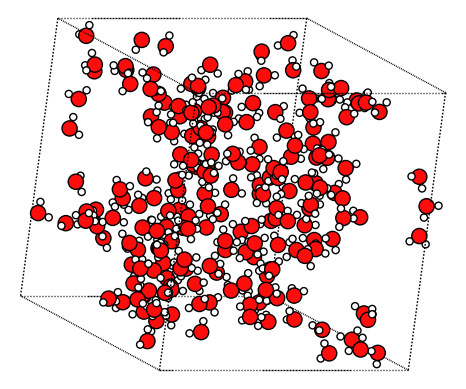

In [12]:
# 1. Force the translation back to a multi-frame .pdb file
!echo "0" | gmx trjconv -f em.trr -s em.tpr -o gromacs_lattice.pdb -pbc mol

# 2. Fix the names and draw the GIF
import os
import time
import ase.io
from IPython.display import display, FileLink

time.sleep(2) # Gives your Mac a moment to write the new file

pdb_file = "gromacs_lattice.pdb"
fixed_pdb_file = "gromacs_lattice_fixed.pdb"
gif_filename = "GROMACS_D2O_Lattice.gif"

if not os.path.exists(pdb_file) or os.path.getsize(pdb_file) == 0:
    print(f"❌ ERROR: {pdb_file} is still missing. Check the GROMACS output.")
else:
    print(f"✅ Found {pdb_file}! Fixing Deuterium names for the animator...")
    
    # Find and Replace DW1 and DW2 with standard Hydrogen
    with open(pdb_file, "r") as f:
        lines = f.readlines()
        
    with open(fixed_pdb_file, "w") as f:
        for line in lines:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                # Replace the GROMACS labels with standard padded Hydrogen labels
                line = line.replace("DW1", "H  ").replace("DW2", "H  ")
            f.write(line)
            
    print("✅ Names fixed! Reading coordinates...")
    
    # Read the cleaned .pdb file
    traj = ase.io.read(fixed_pdb_file, index=":")
    print(f"Loaded {len(traj)} frames. Rendering 3D animation...")
    
    # Render the GIF
    ase.io.write(gif_filename, traj, format="gif", rotation="15x,30y,0z")
    
    print("\n✅ 3D Lattice animation successfully saved!")
    display(FileLink(gif_filename))